<a href="https://colab.research.google.com/github/thayusky/7DaysOfCode-ML/blob/main/Day1_Exploratory_Data_Analysis_Spotify_Tracks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   # #7DaysOfCode - Day 1: Exploratory Data Analysis of Spotify Tracks
   Goal: understand the data and discover what makes a song popular on Spotify.

In [31]:
import kagglehub

# Download the Spotify Tracks dataset from Kaggle
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")
print(path)

Using Colab cache for faster access to the '-spotify-tracks-dataset' dataset.
/kaggle/input/-spotify-tracks-dataset


In [32]:
import pandas as pd

# Read the CSV file into a DataFrame
df = pd.read_csv(path + "/dataset.csv")

# If you uploaded the file manually, use this line instead:
# df = pd.read_csv("dataset.csv")

In [33]:
# Show the first 5 rows
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [34]:
# Number of rows and columns
df.shape

(114000, 21)

In [35]:
# Column names, data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [36]:
# Count missing values in each column
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [37]:
# Count duplicated rows
df.duplicated().sum()

np.int64(0)

In [38]:
# Basic statistics for numeric columns
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## 3. Data cleaning

In [39]:
# Remove the extra index column created when the file was saved
df = df.drop(columns=["Unnamed: 0"])
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [40]:
# Remove rows with missing values
df = df.dropna()
df.shape

(113999, 20)

In [41]:
# How many times does each track appear?
df["track_id"].value_counts().head(10)

,count
track_id,
6S3JlDAGk3uu3NtZbPnuhS,9
2kkvB3RNRzwjFdGhaUA0tz,8
2Ey6v4Sekh3Z0RUSISRosD,8
5sqkarfxe7UejHTlCtHCLS,7
6bzWr3EpSEolVwlbLk58il,7
0YLSjVxSb5FT1Bo8Tnxr8j,7
61202Zzk9rk4bPMZLh2gr6,7
36NwMJRaCy7x77xYGJiG2M,7
5ZsAhuQ24mWHiduaxJqnhW,7


## 4. Answering questions with the data

In [42]:
#### Question 1: What are the 100 most popular songs?
# Keep only one row per track, then sort by popularity
top_100 = (
    df.drop_duplicates(subset="track_id")
      .sort_values(by="popularity", ascending=False)
      .head(100)
)

top_100[["track_name", "artists", "popularity", "track_genre"]]

,track_name,artists,popularity,track_genre
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100,dance
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99,hip-hop
20008,I'm Good (Blue),David Guetta;Bebe Rexha,98,dance
67356,La Bachata,Manuel Turizo,98,latin
67358,Me Porto Bonito,Bad Bunny;Chencho Corleone,97,latin
...,...,...,...,...
107001,Everybody Wants To Rule The World,Tears For Fears,87,synth-pop
20251,Numb,Marshmello;Khalid,87,dance
3300,Miss You,Oliver Tree;Robin Schulz,87,alternative
51051,THATS WHAT I WANT,Lil Nas X,87,hip-hop


In [43]:
#### Question 2: Which music genres are the most popular?
# Average popularity per genre, from highest to lowest
genre_popularity = (
    df.groupby("track_genre")["popularity"]
      .mean()
      .sort_values(ascending=False)
)

genre_popularity.head(10)

,popularity
track_genre,
pop-film,59.283000
k-pop,56.952953
chill,53.651000
sad,52.379000
grunge,49.594000
indian,49.539000
anime,48.772000
emo,48.128000
sertanejo,47.866000


In [44]:
# How many times does each track_id appear?
df["track_id"].value_counts().head(10)

,count
track_id,
6S3JlDAGk3uu3NtZbPnuhS,9
2kkvB3RNRzwjFdGhaUA0tz,8
2Ey6v4Sekh3Z0RUSISRosD,8
5sqkarfxe7UejHTlCtHCLS,7
6bzWr3EpSEolVwlbLk58il,7
0YLSjVxSb5FT1Bo8Tnxr8j,7
61202Zzk9rk4bPMZLh2gr6,7
36NwMJRaCy7x77xYGJiG2M,7
5ZsAhuQ24mWHiduaxJqnhW,7


### 📌 Key lesson: duplicated songs

> **"For this specific question, does it make sense to count the song more than once?"**

In this dataset, the same song can appear several times because it can be classified under more than one genre. Each copy has the same `track_id` and the same `popularity`; only the `track_genre` column changes.

**Repetition does not change popularity.** Popularity is a value provided by Spotify (from 0 to 100), not a count of how many times a song appears in the dataset.

**However, repetition can affect counts and averages**, depending on the question:

- **Top 100 songs:** remove duplicates ❌, otherwise the same song would take several positions.
- **Overall average popularity:** remove duplicates ❌, otherwise repeated songs would carry more weight than the others.
- **Popularity by genre:** keep duplicates ✅, because the song genuinely belongs to each of those genres.

There is no fixed rule such as "always remove duplicates". Before analysing the data, always ask the question above.

### Question 3: Who are the most popular artists?

In [45]:
# Keep one row per track (each song should count only once per artist)
tracks = df.drop_duplicates(subset="track_id").copy()

# Split the artists into a list, using ";" as the separator
tracks["artist"] = tracks["artists"].str.split(";")

# Create one row for each artist of each song
artists = tracks.explode("artist")

artists[["track_name", "artists", "artist"]].head(10)

,track_name,artists,artist
0,Comedy,Gen Hoshino,Gen Hoshino
1,Ghost - Acoustic,Ben Woodward,Ben Woodward
2,To Begin Again,Ingrid Michaelson;ZAYN,Ingrid Michaelson
2,To Begin Again,Ingrid Michaelson;ZAYN,ZAYN
3,Can't Help Falling In Love,Kina Grannis,Kina Grannis
4,Hold On,Chord Overstreet,Chord Overstreet
5,Days I Will Remember,Tyrone Wells,Tyrone Wells
6,Say Something,A Great Big World;Christina Aguilera,A Great Big World
6,Say Something,A Great Big World;Christina Aguilera,Christina Aguilera
7,I'm Yours,Jason Mraz,Jason Mraz


In [46]:
# Artists with the most songs in the dataset
artists["artist"].value_counts().head(10)

,count
artist,
George Jones,332
Pritam,323
Wolfgang Amadeus Mozart,305
Arijit Singh,259
Hank Williams,243
my little airport,171
Glee Cast,170
Yuvan Shankar Raja,167
Hillsong Worship,167


In [47]:
# Average popularity and number of songs per artist
artist_stats = artists.groupby("artist")["popularity"].agg(["mean", "count"])

# Only consider artists with at least 10 songs
artist_stats[artist_stats["count"] >= 10].sort_values(by="mean", ascending=False).head(10)

,mean,count
artist,,
Frank Ocean,74.142857,21
Radiohead,73.545455,11
The Neighbourhood,73.481481,27
System Of A Down,72.750000,12
Stray Kids,72.608696,23
TWICE,72.470588,17
Travis Scott,72.304348,23
SEVENTEEN,70.466667,15
j-hope,70.416667,12


### 📌 Key lesson: copy, split and explode

**1. `.copy()` – making an independent copy**

`tracks = df.drop_duplicates(subset="track_id").copy()`

`.copy()` creates a completely separate table. Any changes made to `tracks` will not affect the original `df`. It is good practice whenever we create a new table from an existing one and plan to modify it.

**2. Creating a new column**

`tracks["artist"] = ...`

Writing `table["new_name"] = something` creates a new column called `new_name`. If the column already exists, it is overwritten.

**3. `.str.split(";")` – cutting text into a list**

Some songs have more than one artist, separated by `;`. `.str.split(";")` cuts the text wherever it finds a `;` and turns it into a list:

| artists | artist |
|---|---|
| Gen Hoshino | ["Gen Hoshino"] |
| Ingrid Michaelson;ZAYN | ["Ingrid Michaelson", "ZAYN"] |

**4. `.explode()` – one row for each item in the list**

`artists = tracks.explode("artist")`

`.explode()` takes each list and creates a separate row for every item in it. The other columns are repeated:

| track_name | artist |
|---|---|
| To Begin Again | Ingrid Michaelson |
| To Begin Again | ZAYN |

This way, each artist is counted individually, rather than "Ingrid Michaelson;ZAYN" being treated as a single artist.

Para você lembrar em português:

.copy() = tirar uma "xerox" da tabela para rabiscar sem estragar o original.
split = tesoura ✂️ que corta o texto.
explode = pega cada lista e "espalha" em várias linhas, uma para cada item. 💥

## 5. Visualising the data

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

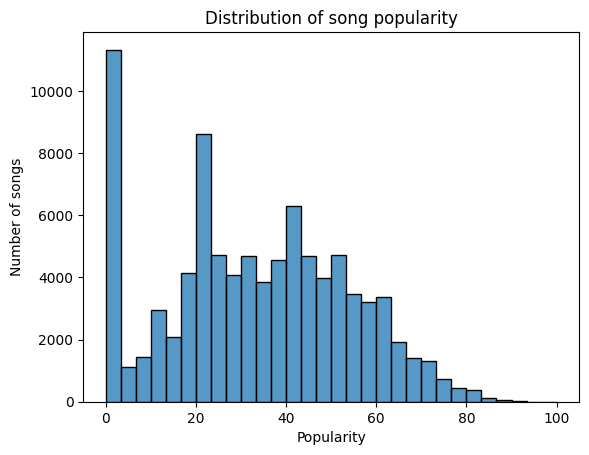

In [49]:
# Distribution of popularity across all songs
sns.histplot(data=tracks, x="popularity", bins=30)
plt.title("Distribution of song popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of songs")
plt.show()

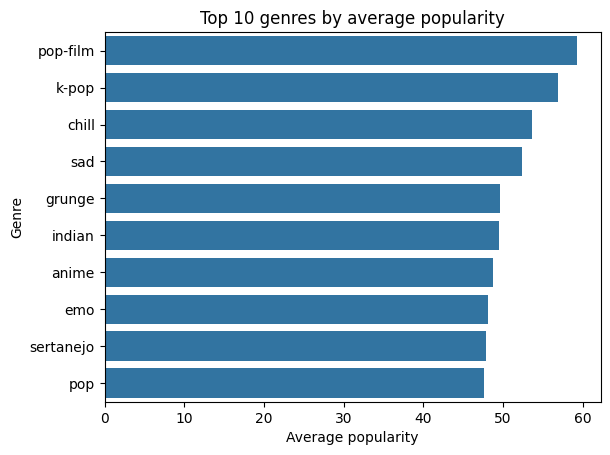

In [50]:
# Top 10 genres by average popularity
top_genres = genre_popularity.head(10)

sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 genres by average popularity")
plt.xlabel("Average popularity")
plt.ylabel("Genre")
plt.show()

In [51]:
artists["artist"].value_counts().head(10)

,count
artist,
George Jones,332
Pritam,323
Wolfgang Amadeus Mozart,305
Arijit Singh,259
Hank Williams,243
my little airport,171
Glee Cast,170
Yuvan Shankar Raja,167
Hillsong Worship,167


### 📌 Key lesson: more songs ≠ more popular

Having the most songs in the dataset does not mean being the most popular artist. The way the data was collected strongly influences the results: this dataset appears to sample a similar number of songs per genre, so artists from smaller genres (e.g. country, classical) can appear many times.

> **Always be sceptical and ask: "Where did this data come from?"**

## 6. More visualisations


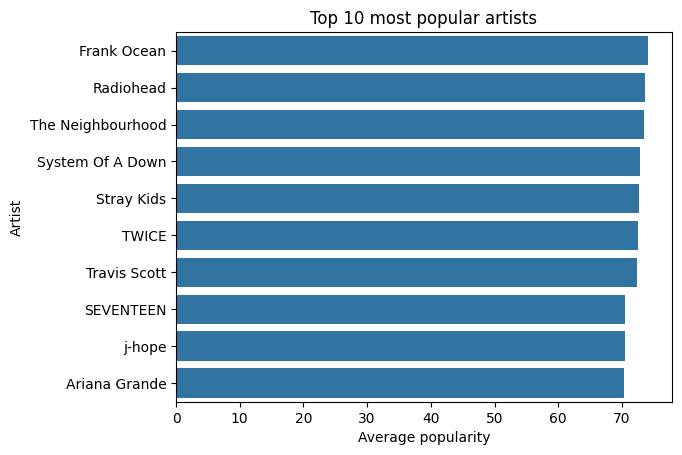

In [52]:
# Top 10 artists by average popularity (at least 10 songs)
top_artists = (
    artist_stats[artist_stats["count"] >= 10]
    .sort_values(by="mean", ascending=False)
    .head(10)
)

sns.barplot(x=top_artists["mean"], y=top_artists.index)
plt.title("Top 10 most popular artists")
plt.xlabel("Average popularity")
plt.ylabel("Artist")
plt.show()

### Are explicit songs more popular?

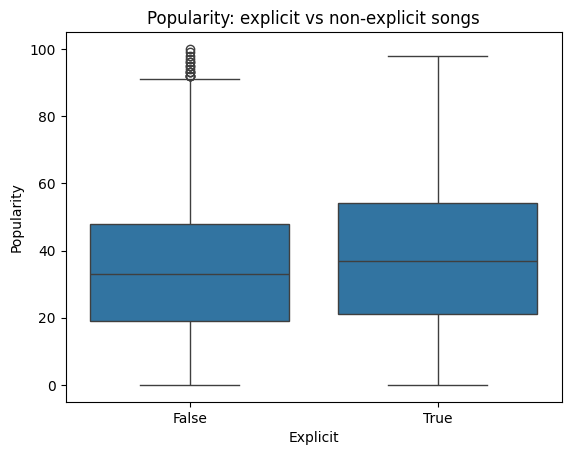

In [53]:
# Compare popularity between explicit and non-explicit songs
sns.boxplot(data=tracks, x="explicit", y="popularity")
plt.title("Popularity: explicit vs non-explicit songs")
plt.xlabel("Explicit")
plt.ylabel("Popularity")
plt.show()

### Is danceability related to popularity?

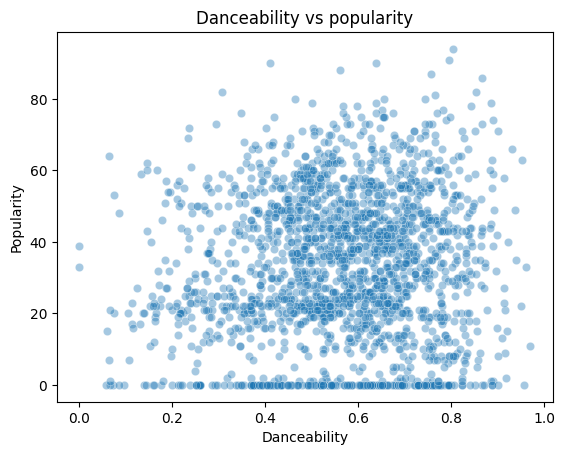

In [54]:
# Use a random sample of 2,000 songs so the chart is easier to read
sample = tracks.sample(2000, random_state=42)

sns.scatterplot(data=sample, x="danceability", y="popularity", alpha=0.4)
plt.title("Danceability vs popularity")
plt.xlabel("Danceability")
plt.ylabel("Popularity")
plt.show()

**Finding:** explicit songs tend to be more popular than non-explicit songs. However, this does not mean that being explicit *causes* a song to be more popular; other factors, such as genre, may explain the difference.

### Correlation between numeric features

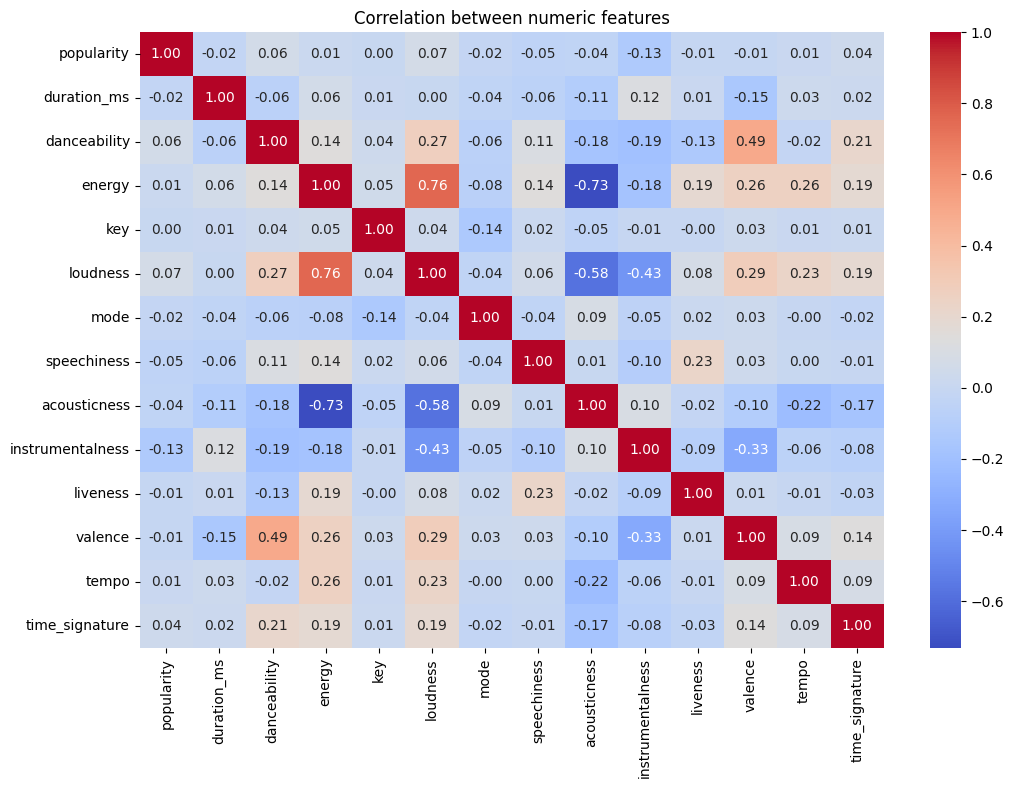

In [55]:
# Select only the numeric columns
numeric = tracks.select_dtypes(include="number")

# Calculate the correlation between every pair of columns
correlation = numeric.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation between numeric features")
plt.show()

**Findings:**
- The strongest correlations are between **energy and loudness** (0.76) and between **energy and acousticness** (-0.73). Energetic songs tend to be louder and less acoustic.
- **Danceability and valence** are moderately correlated (0.49): more danceable songs tend to sound happier.
- **Popularity has a very weak correlation with every feature** (all close to zero). No single feature explains popularity on its own, so a Machine Learning model will need to combine several features.

## 7. Investigation: songs with zero popularity

**Hypotheses:**
1. Nobody listens to these songs.
2. They belong to specific, less popular genres.
3. They are repeated versions of the same song (e.g. re-releases or compilations), and Spotify gives the popularity to the "main" version only.

In [56]:
# Select the songs with zero popularity
zeros = tracks[tracks["popularity"] == 0]

print("Songs with zero popularity:", len(zeros))
print("Percentage of all songs:", round(len(zeros) / len(tracks) * 100, 1), "%")

Songs with zero popularity: 9447
Percentage of all songs: 10.5 %


In [57]:
# Which genres have the most songs with zero popularity?
zeros["track_genre"].value_counts().head(10)

,count
track_genre,
iranian,648
romance,555
country,554
dance,452
latin,432
jazz,409
alt-rock,349
classical,338
blues,322


In [58]:
# Pick the first song with zero popularity
example = zeros.iloc[0]
print(example["track_name"], "-", example["artists"])

# Look for all songs with the same name and the same artists
tracks[
    (tracks["track_name"] == example["track_name"]) &
    (tracks["artists"] == example["artists"])
][["track_id", "track_name", "artists", "album_name", "popularity"]]

93 Million Miles - Jason Mraz


,track_id,track_name,artists,album_name,popularity
23,0BUuuEvNa5T4lMaewyiudB,93 Million Miles,Jason Mraz,Coffee Moment,0
75,38jy6kRlPt8z1GUS9WXeNh,93 Million Miles,Jason Mraz,Love Is a Four Letter Word,67


**Clue:** "93 Million Miles" by Jason Mraz appears twice with different `track_id` values. The version on the original album (*Love Is a Four Letter Word*) has a popularity of 67, whereas the version on a compilation album (*Coffee Moment*) has a popularity of 0. People do listen to the song, but mainly through the original version. This supports hypothesis 3, although a single example is not enough to prove it.

In [59]:
# Mark songs that appear more than once with the same name and artists
tracks["has_other_version"] = tracks.duplicated(subset=["track_name", "artists"], keep=False)

# Of the zero-popularity songs, what percentage have another version?
zeros_check = tracks[tracks["popularity"] == 0]
print(round(zeros_check["has_other_version"].mean() * 100, 1), "% of zero-popularity songs have another version")

# Compare with the rest of the songs
others = tracks[tracks["popularity"] > 0]
print(round(others["has_other_version"].mean() * 100, 1), "% of the other songs have another version")

57.7 % of zero-popularity songs have another version
9.5 % of the other songs have another version


**Conclusion:**
- 57.7% of zero-popularity songs have another version with the same name and artists, compared with only 9.5% of the other songs.
- This strongly supports hypothesis 3: many zero-popularity songs are re-releases or compilation versions, and the popularity is given to the original version.
- The remaining 42% may be songs that are genuinely rarely played, or versions with slightly different names (e.g. "Remastered" or "Live"), which our exact-match check cannot detect.

**Why this matters for Machine Learning:** these songs do not have zero popularity because of their musical features, but because of how Spotify counts plays. They could confuse a model, so we will need to decide whether to remove them before training.